 Data loaded and preprocessed successfully.

 Decision Tree (max_depth=None):
Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.87      0.75      0.81        36
           1       0.69      0.83      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60



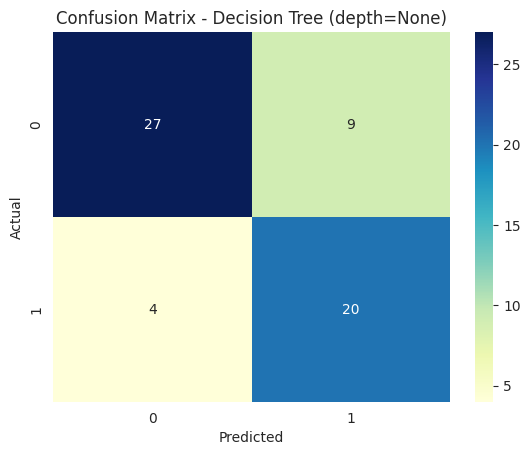

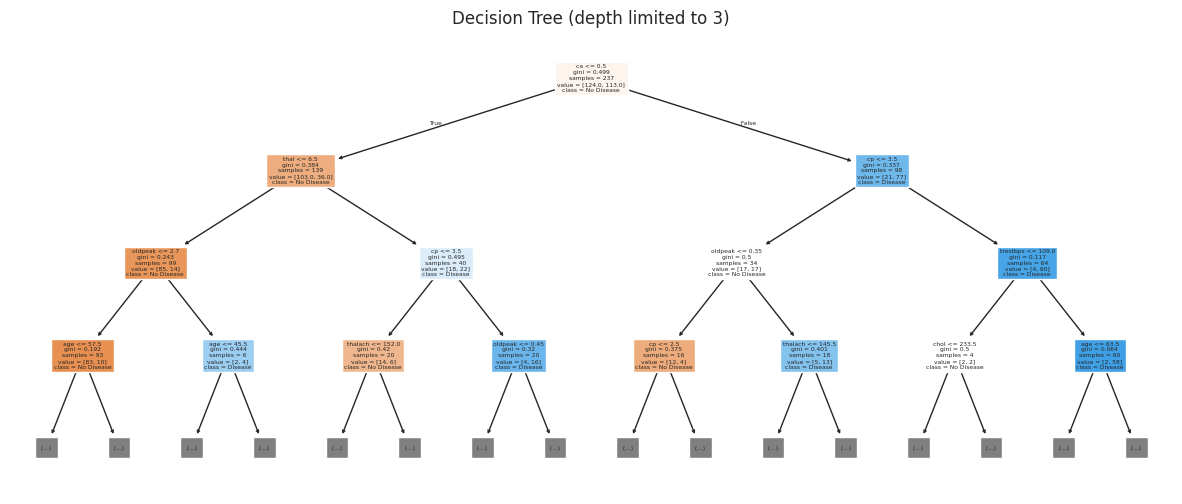


 Decision Tree (max_depth=4):
Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.87      0.75      0.81        36
           1       0.69      0.83      0.75        24

    accuracy                           0.78        60
   macro avg       0.78      0.79      0.78        60
weighted avg       0.80      0.78      0.79        60



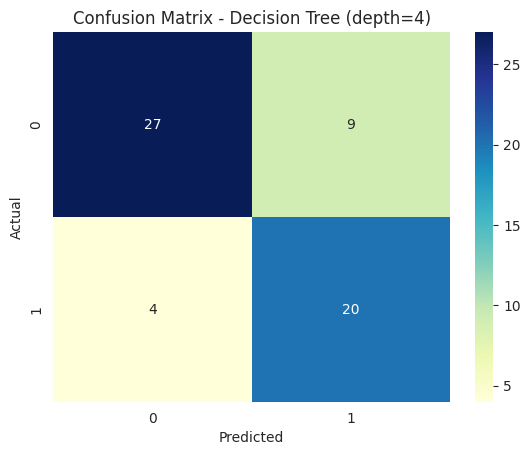


 Random Forest:
Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60


 Cross-Validation Scores:
Scores: [0.83333333 0.86666667 0.77966102 0.76271186 0.79661017]
Mean Accuracy: 0.8077966101694916


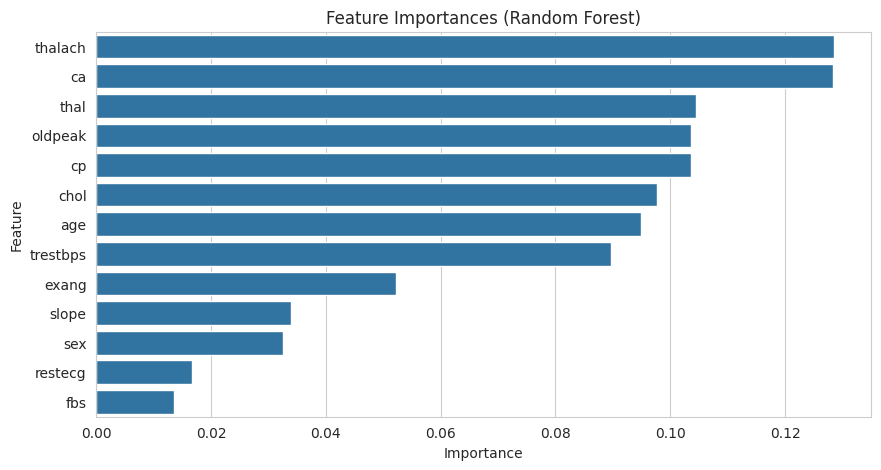


 Task Completed Successfully (Function-Based Version).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

# -------------------- Load and Preprocess Data -------------------- #
def load_data():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    column_names = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
    ]
    df = pd.read_csv(url, names=column_names)
    df.replace('?', np.nan, inplace=True)
    df.dropna(inplace=True)

    for col in ['ca', 'thal']:
        df[col] = pd.to_numeric(df[col])

    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

    print(" Data loaded and preprocessed successfully.")
    return df

# -------------------- Prepare Data -------------------- #
def prepare_data(df):
    X = df.drop('target', axis=1)
    y = df['target']
    return train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------- Train and Evaluate Decision Tree -------------------- #
def train_decision_tree(X_train, X_test, y_train, y_test, max_depth=None):
    dtree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dtree.fit(X_train, y_train)
    y_pred = dtree.predict(X_test)

    print(f"\n Decision Tree (max_depth={max_depth}):")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"Confusion Matrix - Decision Tree (depth={max_depth})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return dtree

def visualize_tree(model, feature_names, depth=3):
    plt.figure(figsize=(15, 6))
    plot_tree(model, feature_names=feature_names, class_names=['No Disease', 'Disease'], filled=True, max_depth=depth)
    plt.title(f"Decision Tree (depth limited to {depth})")
    plt.show()

# -------------------- Train and Evaluate Random Forest -------------------- #
def train_random_forest(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("\n Random Forest:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return rf

# -------------------- Cross-Validation -------------------- #
def cross_validate_model(model, X, y):
    print("\n Cross-Validation Scores:")
    scores = cross_val_score(model, X, y, cv=5)
    print("Scores:", scores)
    print("Mean Accuracy:", scores.mean())

# -------------------- Feature Importance -------------------- #
def plot_feature_importance(model, feature_names):
    importances = model.feature_importances_
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=feat_df, x='Importance', y='Feature')
    plt.title("Feature Importances (Random Forest)")
    plt.show()

# -------------------- Main Workflow -------------------- #
def main():
    df = load_data()
    X_train, X_test, y_train, y_test = prepare_data(df)

    # Decision Tree: Unpruned
    dtree = train_decision_tree(X_train, X_test, y_train, y_test)
    visualize_tree(dtree, df.drop('target', axis=1).columns, depth=3)

    # Decision Tree: Pruned
    train_decision_tree(X_train, X_test, y_train, y_test, max_depth=4)

    # Random Forest
    rf = train_random_forest(X_train, X_test, y_train, y_test)
    cross_validate_model(rf, df.drop('target', axis=1), df['target'])
    plot_feature_importance(rf, df.drop('target', axis=1).columns)

    print("\n Task Completed Successfully (Function-Based Version).")

# Run the full pipeline
main()
